In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

In [3]:
# from skimage.segmentation import random_walker

def findRedestPixel(image_path):
    # 读取图片
    img = cv2.imread(image_path)
    if img is None:
        print("read image fail.")
        exit()
    # BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # markers = np.zeros((h, w), dtype=np.uint)
    # markers[0][0] = 1
    # markers[0][w-1] = 1
    
    # 分离通道
    r = img_rgb[:, :, 0].astype(np.float32)
    g = img_rgb[:, :, 1].astype(np.float32)
    b = img_rgb[:, :, 2].astype(np.float32)
    
    # 计算红色程度评分：R - (G+B)/2
    redness = r - (g + b) / 2
    
    # 对每一列找到最大评分的行索引
    col_max_indices = np.argmax(redness, axis=0)  # shape: (w,)
    
    # 获取每一列最红像素的坐标和值
    results = []
    for col in range(w):
        row = col_max_indices[col]
        rgb_value = img_rgb[row, col]
        redness_score = redness[row, col]
        
        results.append({
            'column': col,
            'row': row,
            'position': (col, row),
            'rgb': rgb_value,
            'redness_score': redness_score
        })
        # markers[row, col] = 2
    
    # 输出前10列的结果示例
    for res in results[:10]:
        print(f"列 {res['column']}: 位置 {res['position']}, "
              f"BGR={res['rgb']}, 红色评分={res['redness_score']:.2f}")
    
    # 可视化：在每列最红像素位置画点
    img_marked = img_rgb.copy()
    for col in range(w):
        row = col_max_indices[col]
        cv2.circle(img_marked, (col, row), 1, (0, 255, 0), -1)  # 绿色点
    # labels = random_walker(img_rgb, markers, beta=100, mode='bf', channel_axis=2)
    
    # 显示结果
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_marked)
    plt.title(f"redest")
    plt.axis('off')
    plt.show()

    # fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 3.2), sharex=True, sharey=True)
    # ax1.imshow(img_rgb)
    # ax1.axis('off')
    # ax1.set_title('Noisy data')
    # ax2.imshow(markers, cmap='magma')
    # ax2.axis('off')
    # ax2.set_title('Markers')
    # ax3.imshow(labels, cmap='gray')
    # ax3.axis('off')
    # ax3.set_title('Segmentation')
    # plt.show()

    return results

In [4]:
from scipy.signal import medfilt

def smooth_median(height_vector, kernel_size=5):
    """
    中值滤波
    kernel_size: 核大小，必须为奇数
    """
    smoothed = medfilt(height_vector, kernel_size)
    return smoothed

In [5]:
def plot_basic(height_vector, save_path=None):
    """
    基础折线图
    """
    plt.figure(figsize=(12, 6))
    plt.plot(height_vector, 'b-', linewidth=1.5, label='原始数据')
    # 设置显示范围
    plt.xlim(200, 1400)  # X轴范围：400-1000
    plt.ylim(580, 630)   # Y轴范围：400-600
    plt.xlabel('列索引 (X)', fontsize=12)
    plt.ylabel('高度 (Y)', fontsize=12)
    plt.title('红色直线高度分布', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path == None:
        plt.show()
    else:
        plt.savefig(save_path)  # 保存为PNG格式

列 0: 位置 (0, np.int64(542)), BGR=[64  3 13], 红色评分=56.00
列 1: 位置 (1, np.int64(537)), BGR=[53  0  1], 红色评分=52.50
列 2: 位置 (2, np.int64(538)), BGR=[108   9  30], 红色评分=88.50
列 3: 位置 (3, np.int64(551)), BGR=[145  13  38], 红色评分=119.50
列 4: 位置 (4, np.int64(552)), BGR=[241   1  52], 红色评分=214.50
列 5: 位置 (5, np.int64(550)), BGR=[238   3  32], 红色评分=220.50
列 6: 位置 (6, np.int64(550)), BGR=[241   1  33], 红色评分=224.00
列 7: 位置 (7, np.int64(550)), BGR=[241   1  33], 红色评分=224.00
列 8: 位置 (8, np.int64(552)), BGR=[239   0  20], 红色评分=229.00
列 9: 位置 (9, np.int64(550)), BGR=[241   0  21], 红色评分=230.50


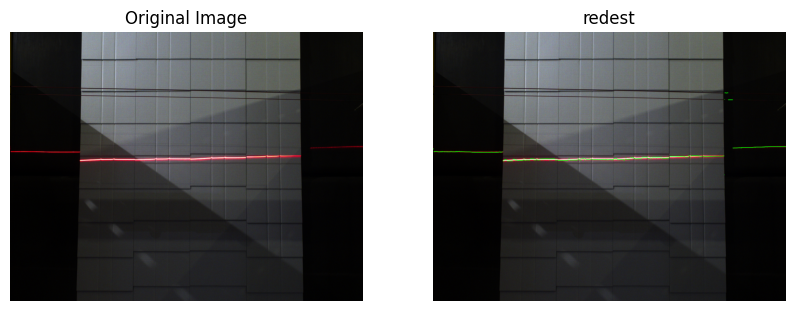

/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/1156609938.py:15: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from

列 0: 位置 (0, np.int64(542)), BGR=[94  0  4], 红色评分=92.00
列 1: 位置 (1, np.int64(542)), BGR=[116   0  18], 红色评分=107.00
列 2: 位置 (2, np.int64(548)), BGR=[166  17  47], 红色评分=134.00
列 3: 位置 (3, np.int64(548)), BGR=[146   0  21], 红色评分=135.50
列 4: 位置 (4, np.int64(542)), BGR=[146   0  20], 红色评分=136.00
列 5: 位置 (5, np.int64(548)), BGR=[153   0  22], 红色评分=142.00
列 6: 位置 (6, np.int64(542)), BGR=[163   0  31], 红色评分=147.50
列 7: 位置 (7, np.int64(548)), BGR=[167   0  21], 红色评分=156.50
列 8: 位置 (8, np.int64(548)), BGR=[185   0  26], 红色评分=172.00
列 9: 位置 (9, np.int64(548)), BGR=[209   0  36], 红色评分=191.00


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas

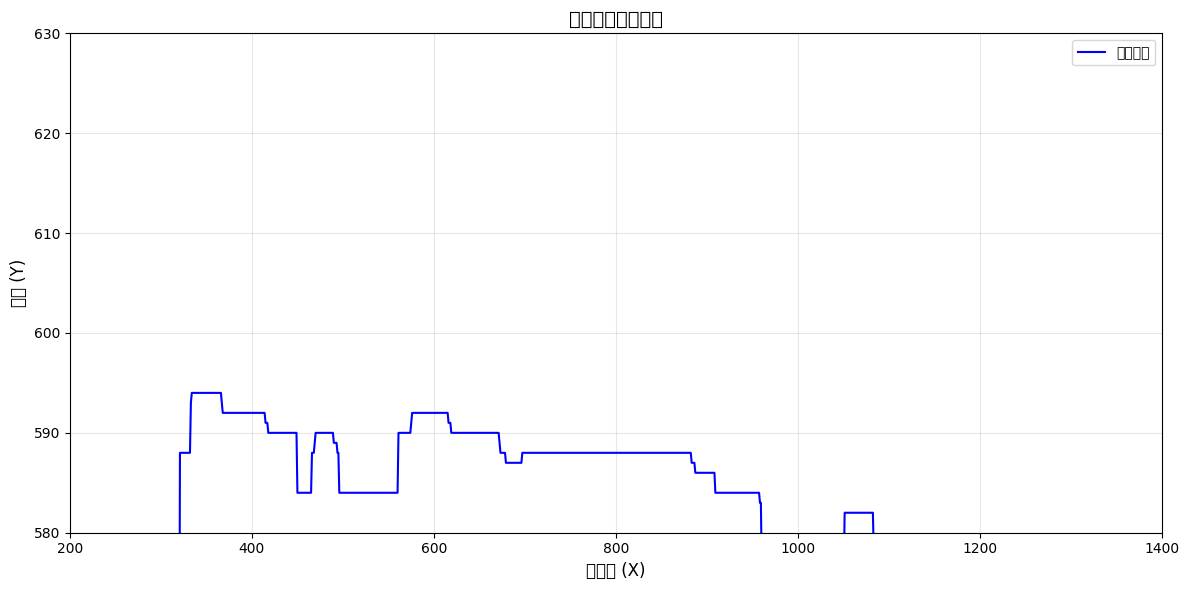

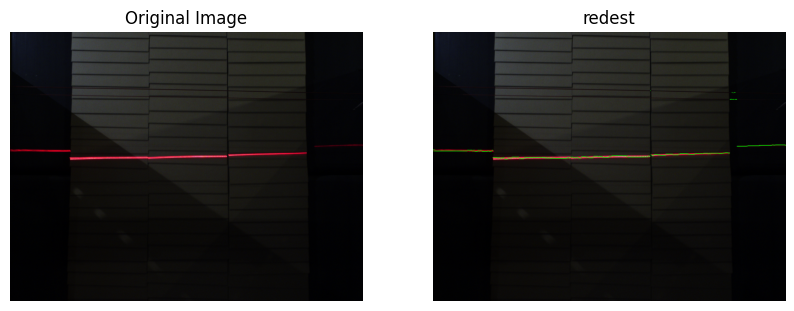

列 0: 位置 (0, np.int64(548)), BGR=[163   0  41], 红色评分=142.50
列 1: 位置 (1, np.int64(548)), BGR=[139   0  28], 红色评分=125.00
列 2: 位置 (2, np.int64(548)), BGR=[139   0  32], 红色评分=123.00
列 3: 位置 (3, np.int64(548)), BGR=[135   0  19], 红色评分=125.50
列 4: 位置 (4, np.int64(548)), BGR=[191   5  48], 红色评分=164.50
列 5: 位置 (5, np.int64(548)), BGR=[157   0  18], 红色评分=148.00
列 6: 位置 (6, np.int64(548)), BGR=[136   0   4], 红色评分=134.00
列 7: 位置 (7, np.int64(548)), BGR=[143   0  18], 红色评分=134.00
列 8: 位置 (8, np.int64(548)), BGR=[151   0  33], 红色评分=134.50
列 9: 位置 (9, np.int64(548)), BGR=[127   0  25], 红色评分=114.50


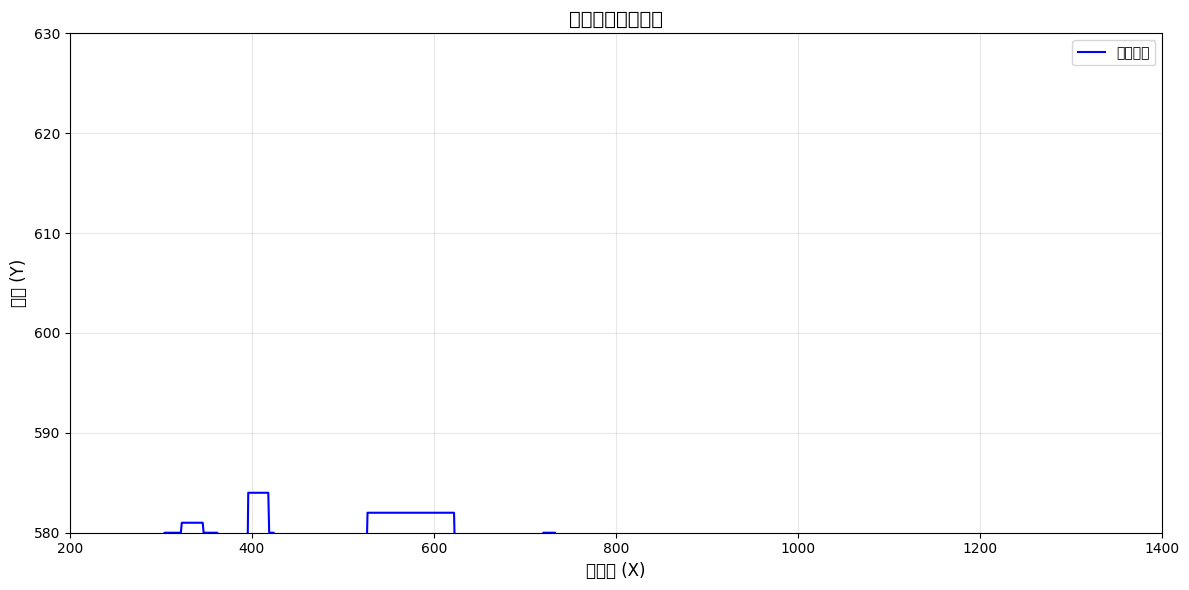

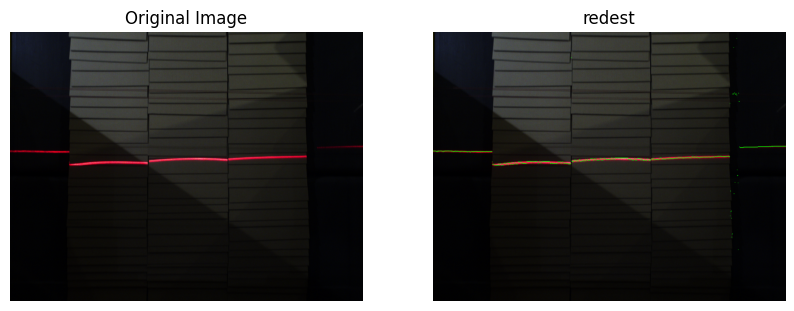

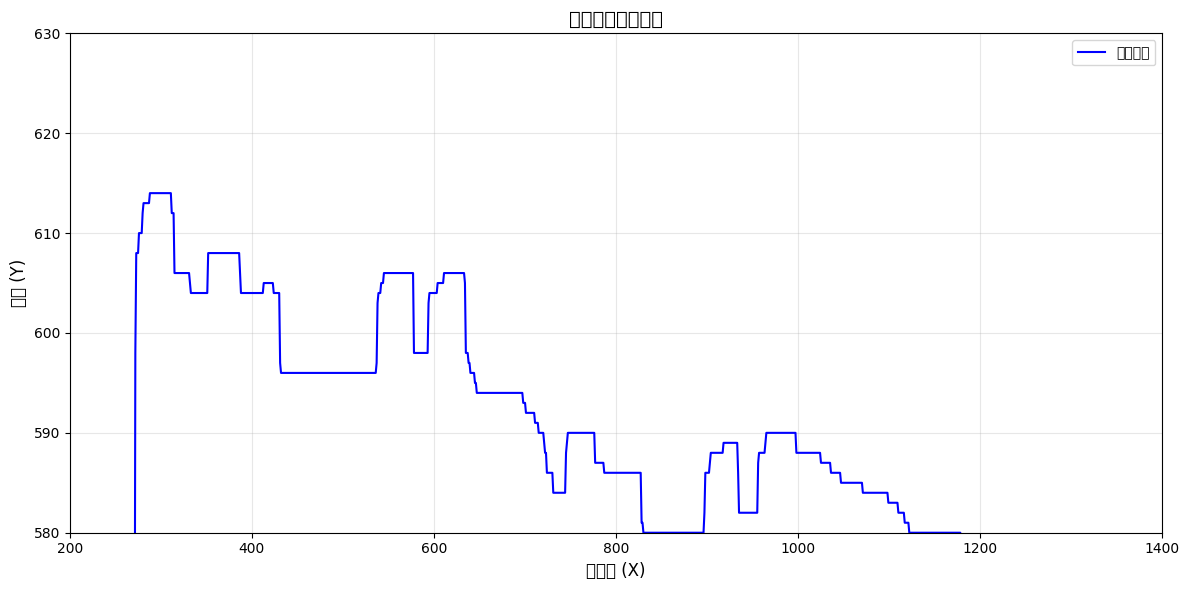

In [6]:
for dirname, _, filenames in os.walk('/kaggle/input/datasets/patrickhuang00017/warpsamples/warp_samples'):
    for filename in filenames[:3]:
        idx = filename.split(".")[0].split("_")[1]
        image_path = os.path.join(dirname, filename)
        results = findRedestPixel(image_path)
        height_vector = []
        for result in results:
            height_vector.append(result["row"])
        height_vector = np.array(height_vector)
        # 1D filter
        height_vector = smooth_median(height_vector, 33)
        height_vector = smooth_median(height_vector, 21)
        height_vector = smooth_median(height_vector, 11)
        height_vector = smooth_median(height_vector, 7)
        height_vector = smooth_median(height_vector, 3)
        # visualization
        plot_basic(height_vector, f"/kaggle/working/{idx}.png")

列 0: 位置 (0, np.int64(542)), BGR=[203   4  51], 红色评分=175.50
列 1: 位置 (1, np.int64(543)), BGR=[160   0  33], 红色评分=143.50
列 2: 位置 (2, np.int64(543)), BGR=[160   0  33], 红色评分=143.50
列 3: 位置 (3, np.int64(544)), BGR=[176   0  26], 红色评分=163.00
列 4: 位置 (4, np.int64(544)), BGR=[201   0  31], 红色评分=185.50
列 5: 位置 (5, np.int64(544)), BGR=[208   0  36], 红色评分=190.00
列 6: 位置 (6, np.int64(544)), BGR=[214   0  38], 红色评分=195.00
列 7: 位置 (7, np.int64(544)), BGR=[226   0  41], 红色评分=205.50
列 8: 位置 (8, np.int64(544)), BGR=[239   0  48], 红色评分=215.00
列 9: 位置 (9, np.int64(544)), BGR=[234   0  38], 红色评分=215.00


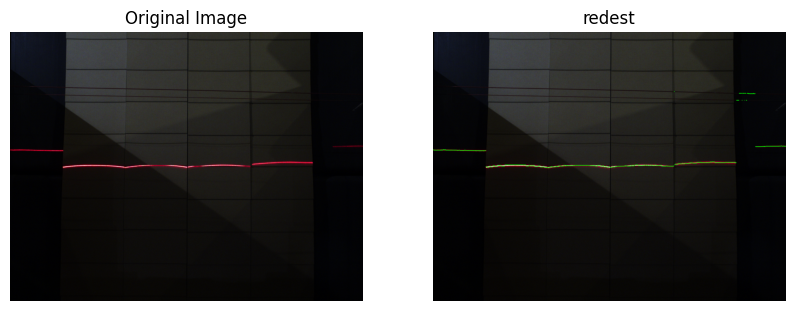

/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/455083829.py:24: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s

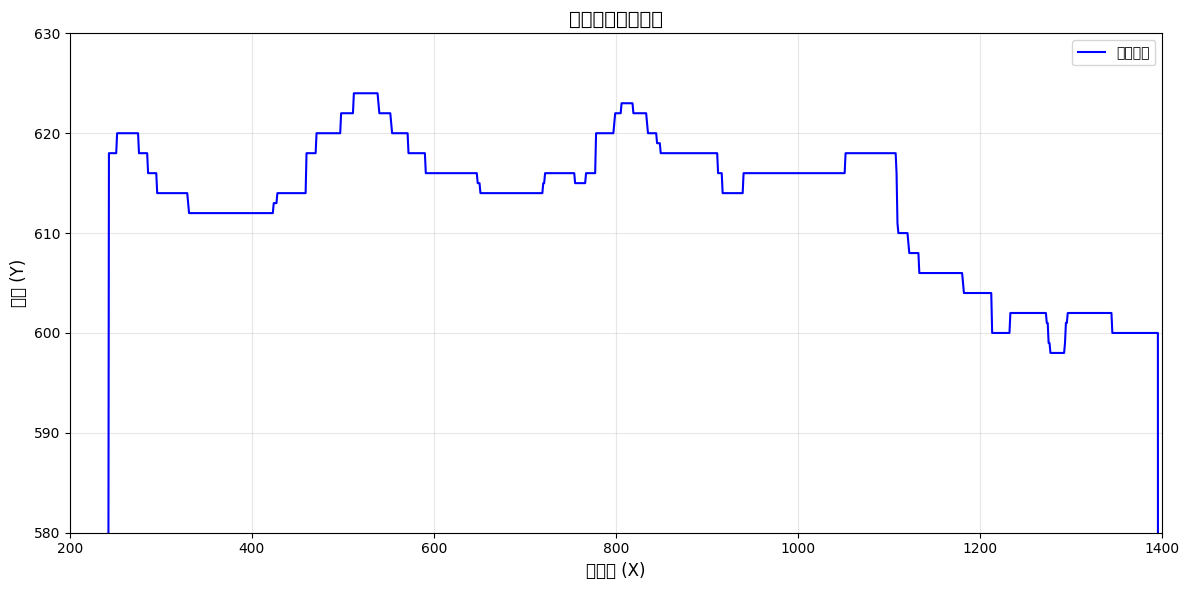

In [7]:
target_path = "/kaggle/input/datasets/patrickhuang00017/warpsamples/warp_samples/image_2679.png"
results = findRedestPixel(target_path)
height_vector = []
for result in results:
    height_vector.append(result["row"])
height_vector = np.array(height_vector)
# 1D filter
height_vector = smooth_median(height_vector, 33)
height_vector = smooth_median(height_vector, 21)
height_vector = smooth_median(height_vector, 11)
height_vector = smooth_median(height_vector, 7)
height_vector = smooth_median(height_vector, 3)
# visualization
plt.figure(figsize=(12, 6))
plt.plot(height_vector, 'b-', linewidth=1.5, label='原始数据')
# 设置显示范围
plt.xlim(200, 1400)  # X轴范围：400-1000
plt.ylim(580, 630)   # Y轴范围：400-600
plt.xlabel('列索引 (X)', fontsize=12)
plt.ylabel('高度 (Y)', fontsize=12)
plt.title('红色直线高度分布', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()